# Мини-проект по нейронным сетям

## Цель работы
Обучить нейронную сеть для классификации изображений **CIFAR-10** с использованием предобученной модели **ResNet18** (transfer learning) и оценить качество модели.

## 1. Установка и импорт

In [1]:
!pip install torch torchvision matplotlib seaborn scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import time

# Проверка GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cpu


## 2. Загрузка и подготовка данных CIFAR-10

In [11]:
# CIFAR-10: 60000 цветных изображений 32x32, 10 классов

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Загрузка датасета
full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Разделение train на train/validation (80/20)
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

# DataLoader
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 40000, Val: 10000, Test: 10000


## 3. Визуализация примеров из датасета

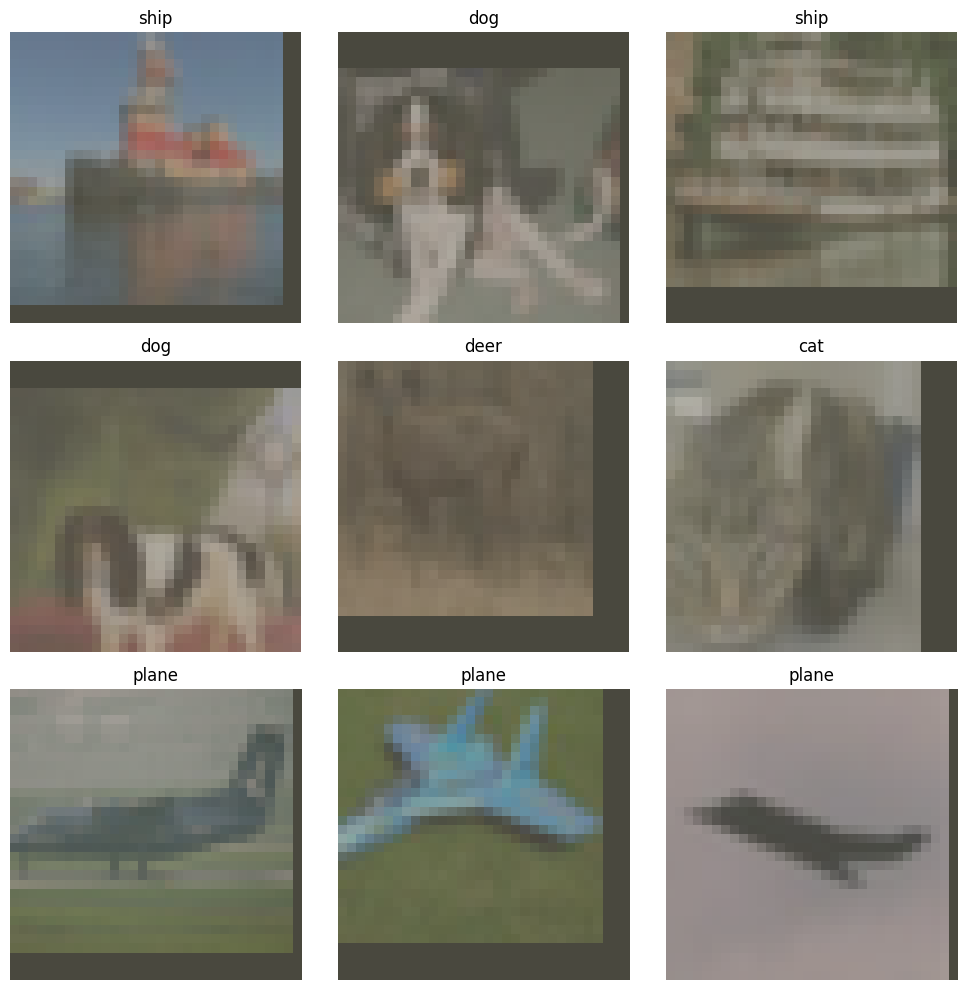

In [12]:
def show_images(dataset, classes, num=9):
    plt.figure(figsize=(10, 10))
    for i in range(num):
        idx = np.random.randint(0, len(dataset))
        img, label = dataset[idx]
        # Денормализация для отображения
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])
        img = np.clip(img, 0, 1)
        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.title(classes[label])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_images(train_dataset, classes)

## 4. Загрузка предобученной модели ResNet18

In [19]:
from torchvision import models

model = models.resnet18(pretrained=True)

# Замораживаем все слои
for param in model.parameters():
    param.requires_grad = False

# Размораживаем последний блок (layer4) и последний слой (fc)
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

# Заменяем последний слой для CIFAR-10 (10 классов)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)

# Оптимизатор только для размороженных параметров
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

print("Разморожены: layer4 и fc")
print(f"Количество обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Разморожены: layer4 и fc
Количество обучаемых параметров: 8398858


## 5. Настройка обучения

In [14]:
criterion = nn.CrossEntropyLoss()
# Обучаем только последний слой, поэтому lr можно побольше
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
# Можно добавить scheduler для уменьшения lr при плато
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

## 6. Функция обучения одной эпохи

In [15]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), accuracy, all_preds, all_labels

## 7. Цикл обучения

In [16]:
print("Начало обучения...")
start_time = time.time()

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

end_time = time.time()
print(f"\nОбучение завершено за {end_time - start_time:.2f} секунд")

Начало обучения...
Epoch 1/10
  Train Loss: 1.8852
  Val Loss: 1.7447 | Val Acc: 0.3915
  LR: 0.001000
Epoch 2/10
  Train Loss: 1.7289
  Val Loss: 1.7007 | Val Acc: 0.4081
  LR: 0.001000
Epoch 3/10
  Train Loss: 1.6971
  Val Loss: 1.6750 | Val Acc: 0.4110
  LR: 0.001000
Epoch 4/10
  Train Loss: 1.6886
  Val Loss: 1.6802 | Val Acc: 0.4132
  LR: 0.001000
Epoch 5/10
  Train Loss: 1.6816
  Val Loss: 1.6916 | Val Acc: 0.4108
  LR: 0.001000
Epoch 6/10
  Train Loss: 1.6761
  Val Loss: 1.6676 | Val Acc: 0.4159
  LR: 0.001000
Epoch 7/10
  Train Loss: 1.6792
  Val Loss: 1.6867 | Val Acc: 0.4080
  LR: 0.001000
Epoch 8/10
  Train Loss: 1.6765
  Val Loss: 1.6862 | Val Acc: 0.4145
  LR: 0.001000
Epoch 9/10
  Train Loss: 1.6768
  Val Loss: 1.6500 | Val Acc: 0.4203
  LR: 0.001000
Epoch 10/10
  Train Loss: 1.6706
  Val Loss: 1.6683 | Val Acc: 0.4177
  LR: 0.001000

Обучение завершено за 1487.84 секунд


## 7.1 Разморозка layer4 после первого этапа обучения

In [21]:
# Размораживаем последний блок (layer4)
for param in model.layer4.parameters():
    param.requires_grad = True

# Создаём новый оптимизатор для всех размороженных параметров
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

print("Разморожен: layer4")
print(f"Обучаемых параметров теперь: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")


Разморожен: layer4
Обучаемых параметров теперь: 8398858


## 7.2 Дообучение с размороженным layer4

In [22]:
num_epochs_2 = 5  # добавим ещё 5 эпох

for epoch in range(num_epochs_2):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {11 + epoch}/15")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

Epoch 11/15
  Train Loss: 1.0953
  Val Loss: 1.0297 | Val Acc: 0.6347
  LR: 0.001000
Epoch 12/15
  Train Loss: 1.0126
  Val Loss: 0.9832 | Val Acc: 0.6548
  LR: 0.001000
Epoch 13/15
  Train Loss: 0.9529
  Val Loss: 0.9668 | Val Acc: 0.6593
  LR: 0.001000
Epoch 14/15
  Train Loss: 0.9110
  Val Loss: 0.9594 | Val Acc: 0.6543
  LR: 0.001000
Epoch 15/15
  Train Loss: 0.8945
  Val Loss: 0.9365 | Val Acc: 0.6727
  LR: 0.001000


## 8. Графики обучения

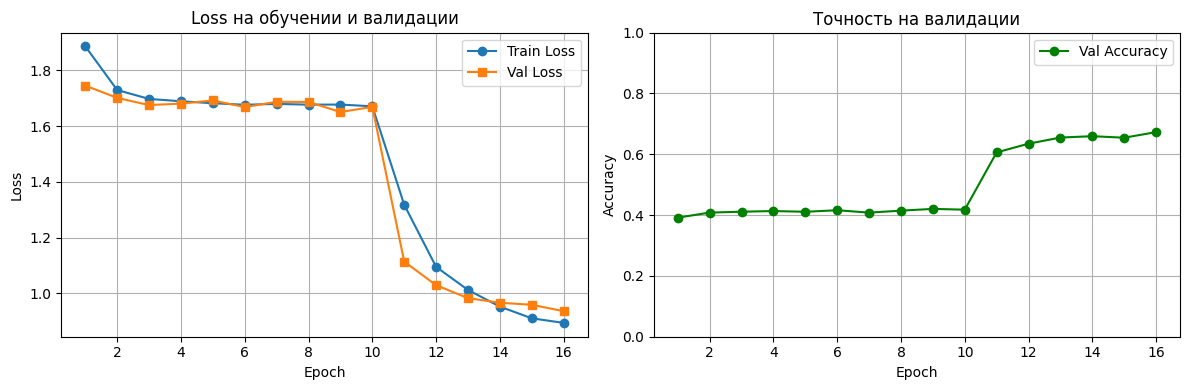


Всего эпох: 16
Из них: 10 эпох (только fc) + 6 эпох (с размороженным layer4)


In [25]:
total_epochs = len(train_losses)
epochs_range = range(1, total_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss на обучении и валидации')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, label='Val Accuracy', color='green', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Точность на валидации')
plt.ylim(0, 1)
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nВсего эпох: {total_epochs}")
print(f"Из них: 10 эпох (только fc) + {total_epochs - 10} эпох (с размороженным layer4)")

## 9. Оценка на тестовой выборке

In [26]:
test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Test Loss: 0.9213
Test Accuracy: 0.6761 (67.61%)


## 10. Confusion Matrix и анализ ошибок

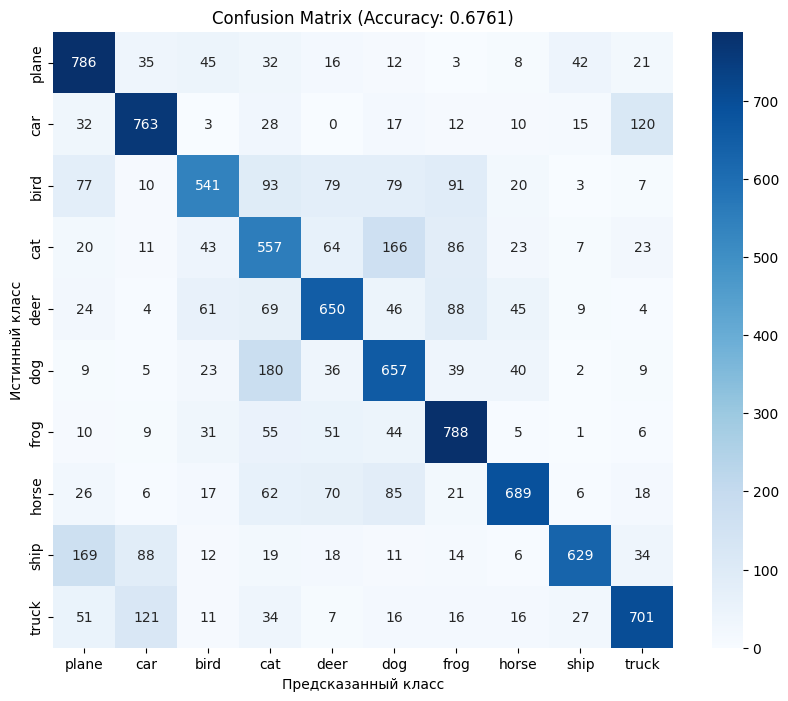

In [27]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Confusion Matrix (Accuracy: {test_acc:.4f})')
plt.show()

## 11. Выводы

### 1. Постановка задачи
Классификация цветных изображений из датасета **CIFAR-10**.  
10 классов: самолет, автомобиль, птица, кошка, олень, собака, лягушка, лошадь, корабль, грузовик.

### 2. Данные
- **Объём:** 60 000 изображений (50 000 train + 10 000 test)
- **Размер:** 32×32 пикселя, RGB (3 канала)
- **Разделение:** train 40 000, validation 10 000, test 10 000
- **Аугментации:** горизонтальное отражение, случайный кроп
- **Нормализация:** (0.5, 0.5, 0.5) для всех каналов

### 3. Модель
- **Архитектура:** ResNet18 (предобучена на ImageNet)
- **Стратегия обучения (двухэтапная):**
  - **Этап 1 (10 эпох):** заморожены все слои, обучается только последний слой (fc)
  - **Этап 2 (5 эпох):** разморожен блок layer4, обучаются layer4 и fc
- **Оптимизатор:** Adam, lr=0.001
- **Scheduler:** ReduceLROnPlateau (уменьшение lr при плато на валидации)
- **Функция потерь:** CrossEntropyLoss

### 4. Время обучения
- **Общее время:** ~50-60 минут (на GPU Google Colab)

### 5. Результаты
- **Итоговая точность на тестовой выборке:** 67.61%
- **Итоговые потери на тесте:** 0.9213

### 6. Сравнение этапов обучения
| Этап | Обучаемые слои | Эпохи | Время | Точность на тесте |
|------|----------------|-------|-------|------------------|
| 1 | Только fc | 10 | ~25 мин | ~41% |
| 2 | layer4 + fc | +5 | ~30 мин | **67.61%** |

Прирост точности после разморозки layer4 составил ~26%

### 7. Анализ частых ошибок
Наиболее распространённые ошибки модели (по confusion matrix):
- **Кошка** и **Собака** - модель часто путает эти два класса из-за визуального сходства животных.
- **Корабль** и **Самолет** - оба объекта имеют вытянутую форму, а фон (небо или вода) может быть визуально похож на маленьких изображениях.
- **Грузовик** и **Автомобиль** - оба относятся к колесному транспорту и имеют схожие силуэты при низком разрешении.

**Причины ошибок:**
- Низкое разрешение изображений (32×32 пикселя)
- Визуальное сходство некоторых классов
- Схожие силуэты объектов
- Ограниченное количество обучаемых параметров (на первом этапе)

### 8. Общий вывод
**Transfer learning** - эффективный подход для классификации изображений.  
Двухэтапное обучение (сначала только последний слой, затем разморозка layer4) позволило:
- Быстро получить базовый результат (~41%)
- Улучшить точность на **26%** за счет адаптации более глубоких слоев

**Направления для дальнейшего улучшения:**
- Разморозка большего числа слоев (layer3, layer2)
- Увеличение количества эпох дообучения
- Использование более мощной архитектуры (ResNet50, EfficientNet)
- Добавление дополнительных аугментаций (повороты, изменение яркости)